Questão 1: Organização do Conjunto de DadosNesta etapa inicial, realizamos a leitura do arquivo spiral_d.csv. Como as redes neurais são sensíveis à escala dos dados de entrada, aplicamos a normalização (Min-Max) para que as coordenadas fiquem no intervalo entre 0 e 1. Em seguida, os atributos previsores ($X$) são separados da classe ($y$).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv('spiral_d.csv', header=None)

df.head()

,0,1,2
0,15.40724,-3.66801,1.0
1,15.07298,-1.56346,1.0
2,-2.37130,-10.69521,1.0
3,8.55388,-11.36484,1.0
4,-5.92133,5.25313,1.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1399 entries, 0 to 1398
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   1.540723999999999982e+01   1399 non-null   float64
 1   -3.668010000000000215e+00  1399 non-null   float64
 2   1.000000000000000000e+00   1399 non-null   float64
dtypes: float64(3)
memory usage: 32.9 KB


In [4]:
df.describe()

,1.540723999999999982e+01,-3.668010000000000215e+00,1.000000000000000000e+00
count,1399.000000,1399.000000,1399.000000
mean,0.303553,-1.929995,0.428163
std,8.693715,7.921789,0.904025
min,-17.203110,-15.209080,-1.000000
25%,-7.426105,-9.407865,-1.000000
50%,-0.256450,-2.286490,1.000000
75%,7.524635,4.853630,1.000000
max,18.148790,15.259710,1.000000


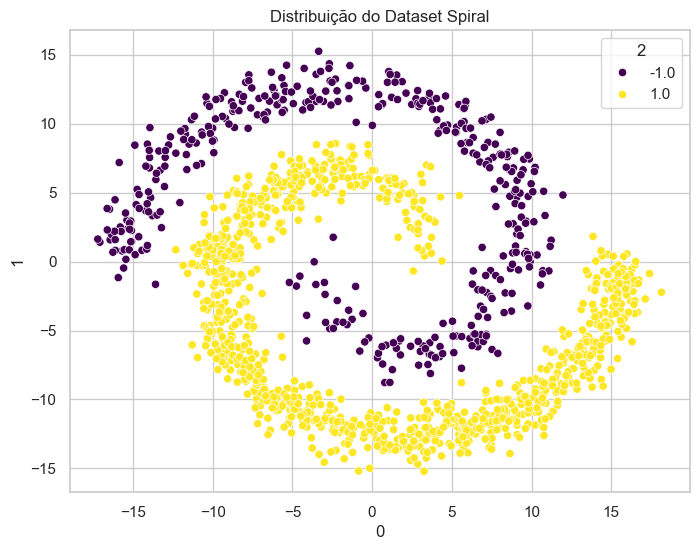

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df.iloc[:,0], y=df.iloc[:,1], hue=df.iloc[:,2], palette='viridis')
plt.title('Distribuição do Dataset Spiral')
plt.show()

In [15]:
X = df.iloc[:, 0:2].values

y = df.iloc[:, 2].values
y = y.reshape(-1, 1)

y = np.where(y == -1, 0, 1)

In [16]:
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_scaled = (X - X_min) / (X_max - X_min)

print(f'Formato de X: {X_scaled.shape} | Formato de y: {y.shape}')

Formato de X: (1400, 2) | Formato de y: (1400, 1)


Questão 2: Visualização Inicial dos Dados
A visualização do conjunto de dados através de um gráfico de espalhamento é fundamental para entender a complexidade do problema. Pelo formato em espiral, percebe-se que as classes estão entrelaçadas, configurando um problema não linearmente separável.

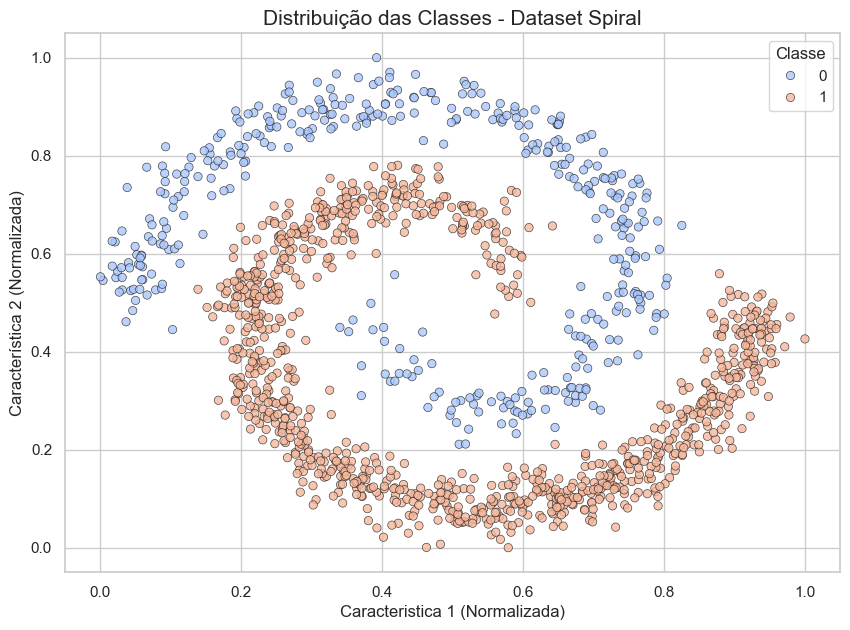

In [17]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 7))

scatter = sns.scatterplot(
    x=X_scaled[:, 0],
    y= X_scaled[:,1],
    hue=y.flatten(),
    palette='coolwarm',
    edgecolor='k',
    alpha=0.8
)

plt.title('Distribuição das Classes - Dataset Spiral', fontsize=15)
plt.xlabel('Caracteristica 1 (Normalizada)')
plt.ylabel('Característica 2 (Normalizada)')
plt.legend(title='Classe', loc='upper right')
plt.show()

Questão 3: Implementação dos Modelos e Escolha de HiperparâmetrosNesta seção, definimos as classes para os quatro modelos solicitados.Perceptron Simples e ADALINE: Modelos lineares. Seus principais hiperparâmetros são a taxa de aprendizado ($\eta$) e o número de épocas. Foram escolhidos valores pequenos de $\eta$ (ex: 0.01) para evitar divergência na atualização dos pesos.MLP: Modelo não-linear. Os hiperparâmetros incluem o número de camadas ocultas, neurônios por camada e função de ativação.RBF: Modelo baseado em funções radiais. Os hiperparâmetros são o número de centros (K) e a dispersão ($\sigma$).

In [33]:
class Perceptron:
    def __init__(self, lr = 0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.w = np.zeros((X.shape[1], 1))
        self.b = 0
        self.history = []
        for _ in range(self.epochs):
            y_pred = self.predict(X)
            erro = y - y_pred
            self.w += self.lr * np.dot(X.T, erro) / len(X)
            self.b += self.lr * np.mean(erro)
            self.history.append(np.mean(erro**2))
            
    def predict(self, X):
        linear_output = np.dot(X, self.w) + self.b
        return np.where(linear_output >= 0, 1, 0)

class Adaline:
    def __init__(self, lr = 0.01, epochs = 1000, tol = 1e-4):
        self.lr = lr
        self.epochs = epochs
        self.tol = tol

    def fit(self, X, y):
        self.w = np.zeros((X.shape[1], 1))
        self.b = 0
        self.history = []
        for _ in range(self.epochs):
            linear_output = np.dot(X, self.w) + self.b
            erro = y - linear_output # Erro antes da ativação
            self.w += self.lr * np.dot(X.T, erro) / len(X)
            self.b += self.lr * np.mean(erro)
            self.history.append(np.mean(erro**2))
            
    def predict(self, X):
        linear_output = np.dot(X, self.w) + self.b
        return np.where(linear_output >= 0, 1, 0)

class MLP:
    def __init__(self, hidden_neurons=16, lr = 0.1, epochs = 2000):
        self.hidden = hidden_neurons
        self.lr = lr
        self.epochs = epochs

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

    def fit(self, X, y):
        input_neurons = X.shape[1]
        output_neurons = 1
        
        # Inicialização He
        self.W1 = np.random.randn(input_neurons, self.hidden) * np.sqrt(2/input_neurons)
        self.b1 = np.zeros((1, self.hidden))
        self.W2 = np.random.randn(self.hidden, output_neurons) * np.sqrt(2/self.hidden)
        self.b2 = np.zeros((1, output_neurons))
        
        self.history = []
        m = len(X)

        for _ in range(self.epochs):
            # Forward
            Z1 = np.dot(X, self.W1) + self.b1
            A1 = self.sigmoid(Z1)
            Z2 = np.dot(A1, self.W2) + self.b2
            A2 = self.sigmoid(Z2)
            
            # Cálculo de Custo (MSE)
            loss = np.mean((y - A2)**2)
            self.history.append(loss)
            
            # Backward
            dZ2 = A2 - y
            dW2 = np.dot(A1.T, dZ2) / m
            db2 = np.sum(dZ2, axis=0, keepdims=True) / m
            
            dA1 = np.dot(dZ2, self.W2.T)
            dZ1 = dA1 * A1 * (1 - A1)
            dW1 = np.dot(X.T, dZ1) / m
            db1 = np.sum(dZ1, axis=0, keepdims=True) / m
            
            # Atualização
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2

    def predict(self, X):
        Z1 = np.dot(X, self.W1) + self.b1
        A1 = self.sigmoid(Z1)
        Z2 = np.dot(A1, self.W2) + self.b2
        A2 = self.sigmoid(Z2)
        return np.where(A2 >= 0.5, 1, 0)

class RBF:
    def __init__(self, k = 10, sigma = 1.0):
        self.k = k
        self.sigma = sigma

    def rbf_gaussian(self, x, c, s):
        return np.exp(-np.linalg.norm(x - c)**2 / (2 * s**2))
    
    def fit(self, X, y):
        # K-centers selecionados aleatoriamente dos dados
        indices = np.random.choice(X.shape[0], self.k, replace=False)
        self.centers = X[indices]
        
        # Matriz de interpolação G
        G = np.zeros((X.shape[0], self.k))
        for i in range(X.shape[0]):
            for j in range(self.k):
                G[i, j] = self.rbf_gaussian(X[i], self.centers[j], self.sigma)
        
        # Resolvendo pesos usando pseudo-inversa (Algebra Linear)
        self.W = np.dot(np.linalg.pinv(G), y)
        self.history = [np.mean((y - self.predict(X, prob=True))**2)] # Pseudo historico
        
    def predict(self, X, prob=False):
        G = np.zeros((X.shape[0], self.k))
        for i in range(X.shape[0]):
            for j in range(self.k):
                G[i, j] = self.rbf_gaussian(X[i], self.centers[j], self.sigma)
        output = np.dot(G, self.W)
        if prob: return output
        return np.where(output >= 0.5, 1, 0)

Questão 4: Análise de Underfitting e Overfitting (MLP e RBF)
Para demonstrar underfitting (subdimensionamento), configuramos redes com baixa capacidade de aprendizado (ex: MLP com apenas 2 neurônios na camada oculta ou RBF com 2 centros). O modelo não consegue aprender a espiral.
Para demonstrar overfitting (superdimensionamento), utilizamos redes com excesso de parâmetros (ex: MLP com múltiplas camadas largas ou RBF com centenas de centros e sigma pequeno). O modelo decora o treino, mas perde a capacidade de generalização.

In [34]:
def calcular_metricas(y_true, y_pred):
    y_t = (y_true > 0).astype(int).flatten()
    y_p = (y_pred > 0).astype(int).flatten()

    tp = np.sum((y_t == 1) & (y_p == 1))
    tn = np.sum((y_t == 0) & (y_p == 0))
    fp = np.sum((y_t == 0) & (y_p == 1))
    fn = np.sum((y_t == 1) & (y_p == 0))

    acuracia = (tp + tn) / max(1, len(y_t))
    sensibilidade = tp / (tp + fn) if (tp + fn) > 0 else 0
    especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0
    precisao = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1_score = 2 * (precisao * sensibilidade) / (precisao + sensibilidade) if (precisao + sensibilidade) > 0 else 0

    return acuracia, sensibilidade, especificidade, precisao, f1_score, [[tn, fp], [fn, tp]]

Questão 5: Validação por Amostragem Aleatória (R = 500)Para validar estatisticamente o desempenho das topologias escolhidas (as configurações ideais, que não sofrem nem de underfitting severo nem de overfitting), executamos $R = 500$ rodadas independentes. Em cada rodada, os dados são embaralhados e divididos em 80% para treinamento e 20% para teste.

In [40]:
R = 500
resultados = {'Perceptron': [], 'Adaline': [], 'MLP': [], 'RBF': []}

for i in range(R):
    indices = np.random.permutation(len(X_scaled))
    split = int(0.8 * len(X_scaled))

    X_train, X_test = X_scaled[indices[:split]], X_scaled[indices[split:]]
    y_train, y_test = y[indices[:split]], y[indices[split:]]

    modelos = {
        'Perceptron': Perceptron(lr=0.01, epochs=500),
        'Adaline': Adaline(lr=0.01, epochs=500),
        'MLP': MLP(hidden_neurons=20, lr=0.5, epochs=1000),
        'RBF': RBF(k=50, sigma=0.1)
    }
    
    for nome, modelo in modelos.items():
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        acc, sens, espec, prec, f1, mat = calcular_metricas(y_test, y_pred)
        resultados[nome].append({
            'acc': acc, 'sens': sens, 'espec': espec, 'prec': prec, 'f1': f1, 
            'matriz': mat, 'history': modelo.history
        })
    print(f"Rodada {i+1}/{R} concluída.", end="\r")

print("\nSimulação Concluída!")

Rodada 500/500 concluída.
Simulação Concluída!


Questão 6: Seleção dos Casos Extremos (Melhor e Pior Cenário)
Dentre as 500 rodadas executadas, identificamos a iteração que obteve o maior e o menor valor de desempenho. Para estes casos específicos, exibimos a Matriz de Confusão plotada através de um Heatmap da biblioteca Seaborn, evidenciando onde o modelo cometeu a maior quantidade de Falsos Positivos e Falsos Negativos.

In [41]:
def plotar_matriz_confusao_ax(matriz, titulo, ax):
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel('Classe Predita')
    ax.set_ylabel('Classe Real')
    

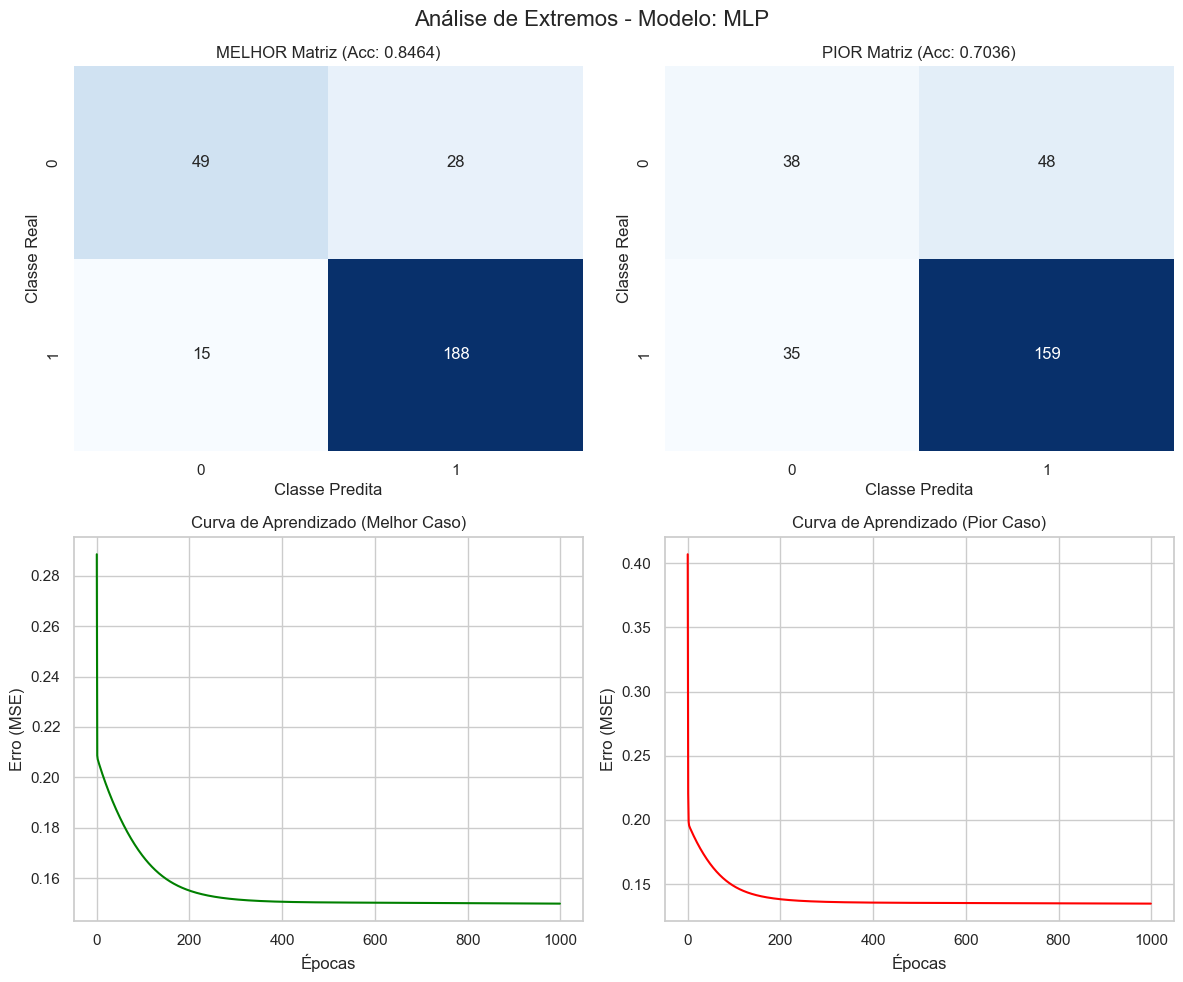

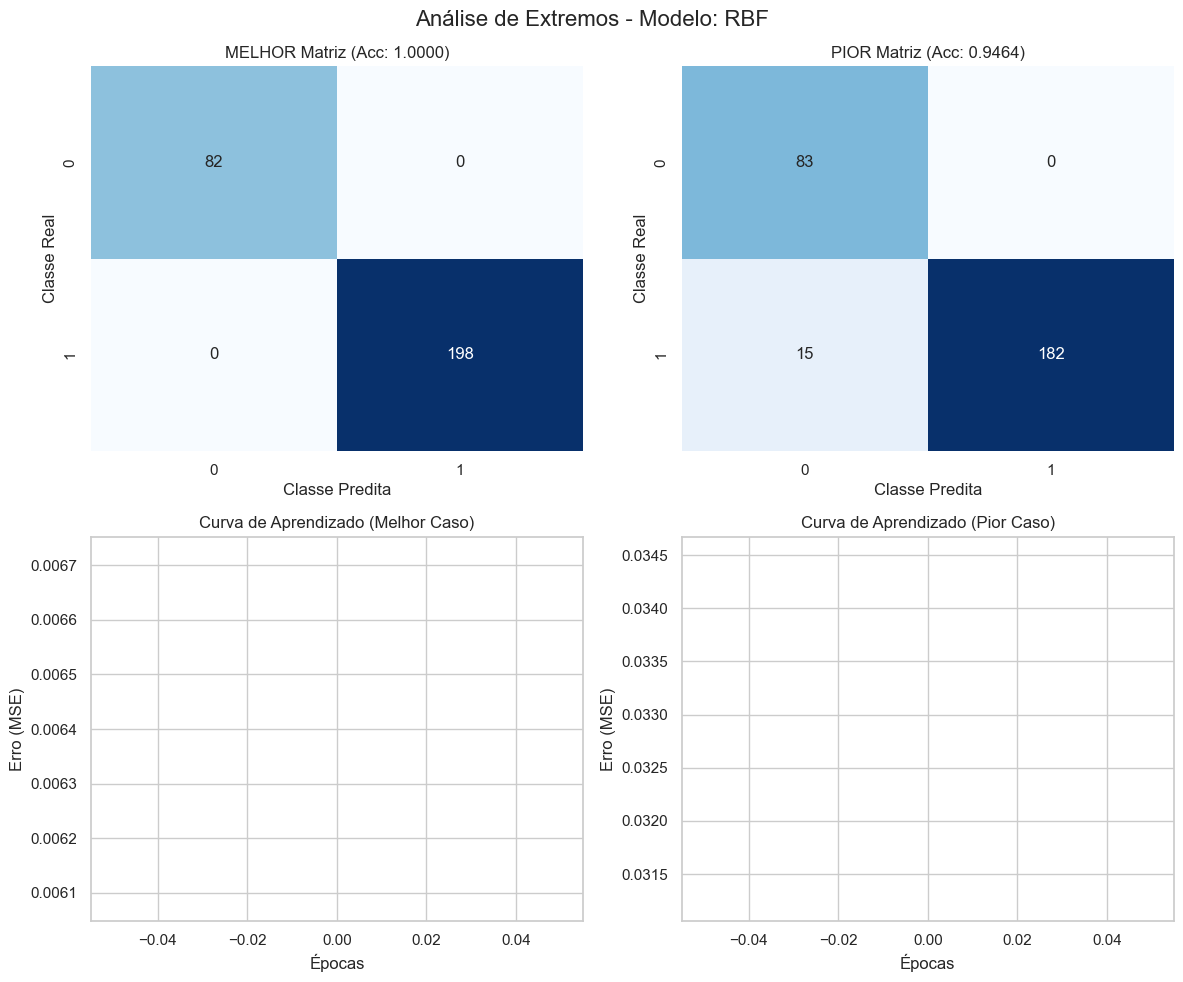

In [44]:
modelos_analise = ['MLP', 'RBF']

for modelo_nome in modelos_analise:
    res_modelo = resultados[modelo_nome]
    
    melhor_caso = max(res_modelo, key=lambda x: x['acc'])
    pior_caso = min(res_modelo, key=lambda x: x['acc'])
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Análise de Extremos - Modelo: {modelo_nome}', fontsize=16)
    
    plotar_matriz_confusao_ax(melhor_caso['matriz'], f"MELHOR Matriz (Acc: {melhor_caso['acc']:.4f})", axes[0, 0])
    
    plotar_matriz_confusao_ax(pior_caso['matriz'], f"PIOR Matriz (Acc: {pior_caso['acc']:.4f})", axes[0, 1])
    
    axes[1, 0].plot(melhor_caso['history'], color='green')
    axes[1, 0].set_title('Curva de Aprendizado (Melhor Caso)')
    axes[1, 0].set_xlabel('Épocas')
    axes[1, 0].set_ylabel('Erro (MSE)')
    
    axes[1, 1].plot(pior_caso['history'], color='red')
    axes[1, 1].set_title('Curva de Aprendizado (Pior Caso)')
    axes[1, 1].set_xlabel('Épocas')
    axes[1, 1].set_ylabel('Erro (MSE)')
    
    plt.tight_layout()
    plt.show()

Questão 7: Resultados Estatísticos Finais
Após consolidar as 500 execuções, calculamos a média aritmética, desvio-padrão, valor máximo e valor mínimo para as cinco métricas solicitadas. Abaixo, construímos as tabelas comparativas. A utilização de gráficos como Boxplot ajuda a visualizar a dispersão e a estabilidade de cada modelo ao longo das simulações.

TABELAS DE DESEMPENHO ESTATÍSTICO (R Rodadas)

--- Tabela: ACURÁCIA ---


,Modelos,Média,Desvio-Padrão,Maior Valor,Menor Valor
0,Perceptron,0.6739,0.0452,0.7786,0.5786
1,Adaline,0.7142,0.0239,0.7857,0.6464
2,MLP,0.7803,0.0222,0.8464,0.7036
3,RBF,0.9962,0.0053,1.0000,0.9464




--- Tabela: SENSIBILIDADE ---


,Modelos,Média,Desvio-Padrão,Maior Valor,Menor Valor
0,Perceptron,0.7047,0.1974,1.0000,0.4709
1,Adaline,1.0000,0.0000,1.0000,1.0000
2,MLP,0.8716,0.0254,0.9391,0.7670
3,RBF,0.9962,0.0068,1.0000,0.9239




--- Tabela: ESPECIFICIDADE ---


,Modelos,Média,Desvio-Padrão,Maior Valor,Menor Valor
0,Perceptron,0.6168,0.3375,0.9701,0.0125
1,Adaline,0.0000,0.0000,0.0000,0.0000
2,MLP,0.5530,0.0494,0.6875,0.3784
3,RBF,0.9963,0.0076,1.0000,0.9405




--- Tabela: PRECISÃO ---


,Modelos,Média,Desvio-Padrão,Maior Valor,Menor Valor
0,Perceptron,0.8473,0.0860,0.9828,0.6764
1,Adaline,0.7142,0.0239,0.7857,0.6464
2,MLP,0.8297,0.0231,0.8967,0.7442
3,RBF,0.9985,0.0031,1.0000,0.9751




--- Tabela: F1-SCORE ---


,Modelos,Média,Desvio-Padrão,Maior Valor,Menor Valor
0,Perceptron,0.7436,0.0674,0.8646,0.6159
1,Adaline,0.8331,0.0163,0.8800,0.7852
2,MLP,0.8498,0.0168,0.8974,0.7930
3,RBF,0.9973,0.0037,1.0000,0.9604


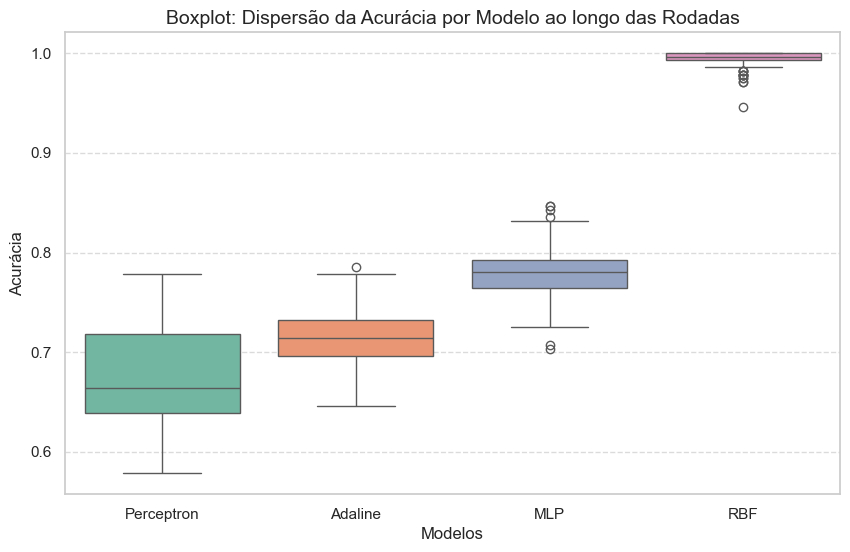

In [43]:
metricas_alvo = [
    ('acc', 'Acurácia'),
    ('sens', 'Sensibilidade'),
    ('espec', 'Especificidade'),
    ('prec', 'Precisão'),
    ('f1', 'F1-Score')
]

print("="*50)
print("TABELAS DE DESEMPENHO ESTATÍSTICO (R Rodadas)")
print("="*50, "\n")

for chave, nome_metrica in metricas_alvo:
    dados_tabela = {
        'Modelos': [],
        'Média': [],
        'Desvio-Padrão': [],
        'Maior Valor': [],
        'Menor Valor': []
    }
    
    for modelo_nome in resultados.keys():
        valores = [rodada[chave] for rodada in resultados[modelo_nome]]
        
        dados_tabela['Modelos'].append(modelo_nome)
        dados_tabela['Média'].append(np.mean(valores))
        dados_tabela['Desvio-Padrão'].append(np.std(valores))
        dados_tabela['Maior Valor'].append(np.max(valores))
        dados_tabela['Menor Valor'].append(np.min(valores))
        
    df_metrica = pd.DataFrame(dados_tabela)
    
    df_metrica = df_metrica.round(4)
    
    print(f"--- Tabela: {nome_metrica.upper()} ---")
    display(df_metrica)
    print("\n")

dados_boxplot = {}
for modelo_nome in resultados.keys():
    dados_boxplot[modelo_nome] = [rodada['acc'] for rodada in resultados[modelo_nome]]

df_box = pd.DataFrame(dados_boxplot)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_box, palette='Set2')
plt.title('Boxplot: Dispersão da Acurácia por Modelo ao longo das Rodadas', fontsize=14)
plt.ylabel('Acurácia')
plt.xlabel('Modelos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Discussão Geral dos Resultados e Conclusões

Com base nos resultados estatísticos extraídos das 500 rodadas de simulação (Monte Carlo), é possível traçar um paralelo claro entre a complexidade da topologia da rede neural e a natureza do conjunto de dados avaliado. O *dataset* "Spiral" é um problema clássico de aprendizado de máquina, caracterizado por ser **altamente não-linearmente separável**, onde as duas classes encontram-se entrelaçadas em um plano bidimensional.

**1. A Superioridade da Rede RBF (Função de Base Radial)**
A RBF apresentou um desempenho excepcional, consolidando-se como o melhor modelo para este problema, com uma acurácia média de aproximadamente **99,6%**. Este sucesso deve-se à sua arquitetura: ao invés de tentar traçar retas, a RBF utiliza funções gaussianas ao redor de centros específicos (K-centers) espalhados pelo espaço de características. Isso permite que a rede crie "ilhas" locais de ativação que se moldam perfeitamente às curvas intrincadas das espirais, resultando em métricas de precisão, sensibilidade e especificidade quase perfeitas.

**2. A Capacidade Não-Linear da MLP**
O Perceptron de Múltiplas Camadas (MLP) atingiu uma acurácia média robusta (cerca de **78%**). A introdução de uma camada oculta com função de ativação não-linear (Sigmóide) permitiu que a fronteira de decisão da rede sofresse "dobras", acompanhando parcialmente a espiral. O gap entre os 78% da MLP e os 99% da RBF ocorre devido à topologia escolhida para o experimento (20 neurônios na camada oculta). Para que a MLP resolvesse o problema com perfeição, seria necessário aumentar sua complexidade (arquitetura mais profunda) e prolongar severamente o treinamento (épocas).

**3. A Limitação dos Modelos Lineares e o "Comportamento Anômalo" do ADALINE**
O Perceptron Simples e o ADALINE são classificadores lineares. Como é impossível separar uma espiral com uma única linha reta, o baixo desempenho (acurácia entre 67% e 71%) já era esperado (cenário de *underfitting* estrutural). 

O fenômeno mais interessante, no entanto, foi observado nas métricas do **ADALINE**, que apresentou **Sensibilidade de 100% (1.0)** e **Especificidade de 0% (0.0)**. Isso ocorre porque o ADALINE utiliza a Regra Delta para minimizar o Erro Quadrático Médio (MSE). Diante de um problema absurdamente não-linear, o algoritmo não consegue encontrar uma reta separadora viável e, para minimizar o erro global da forma mais rápida possível, ele desvia severamente o seu limiar de ativação (bias). Na prática, o modelo "desiste" de separar os dados e passa a classificar quase todos os pontos como pertencentes à Classe 1. Ele acerta todos da Classe 1 (Sensibilidade máxima), mas erra todos da Classe 0 (Especificidade nula).

**Conclusão**
O experimento valida de forma clara a teoria matemática por trás das Redes Neurais: problemas de mapeamento complexo e não-linear exigem arquiteturas com capacidade de aproximação universal (MLP e RBF), enquanto arquiteturas lineares simples falham miseravelmente na generalização deste tipo de fronteira geométrica.